# Physis figures: population diversity & language make-up

Reproduces Figures 1 and 2 of *Transformational Novelty with an Automata Meta-Chemistry*
from the same `.tsv` files used by the `pgfplots` source.

**Expected layout**

```
notebook_dir/
├── physis_figures.ipynb
└── data/
    ├── distinct_genomes.tsv
    ├── distinct_programs.tsv
    ├── distinct_replication_speeds.tsv
    ├── instructions_defined.tsv
    ├── instructions_used.tsv
    ├── instruction_reuse.tsv
    └── micro_ops_per_instruction.tsv
```

Every file is tab-separated with a header row: one `cycle` column plus one column per run
(`seed62`, `seed63`, `seed64`, `seed65`, `seed66`).

Requirements: `pandas`, `matplotlib`.

In [14]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# --- Configuration ----------------------------------------------------------
DATA_DIR = Path()          # where the .tsv files live
OUT_DIR = Path("figures")        # where the rendered figures are written
SEEDS = [62, 63, 64, 65, 66]     # column suffixes: seed62 ... seed66

# ColorBrewer "Paired" A-E, matching \pgfplotsforeachungrouped {62/A,...,66/E}
PAIRED = ["#a6cee3", "#1f78b4", "#b2df8a", "#33a02c", "#fb9a99"]
SEED_COLORS = dict(zip(SEEDS, PAIRED))

# Panel geometry copied from the TeX: width=47mm, height=37mm, horizontal sep=12mm.
# Margins hold the axis labels and tick labels, as pgfplots lets them overflow the sep.
MM = 1 / 25.4                    # mm -> inches
PANEL_W_MM, PANEL_H_MM = 47.0, 37.0
HSEP_MM = 12.0
MARGIN_MM = {"left": 14.0, "right": 3.0, "bottom": 10.0, "top": 3.0}
SCALE = 1.0                      # bump to 2.0 for on-screen inspection; keep 1.0 for the paper

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Nimbus Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 7.0,            # labelscale=0.75 against the ~9pt paper body font
    "axes.labelsize": 7.0,
    "xtick.labelsize": 6.5,      # ticklabelscale=0.75
    "ytick.labelsize": 6.5,
    "axes.linewidth": 0.5,
    "lines.linewidth": 0.75,     # lwidth=0.75 from plotmacros-v2
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2.0,
    "ytick.major.size": 2.0,
    "grid.color": "#b0b0b0",
    "grid.linewidth": 0.3,
    "pdf.fonttype": 42,          # embed TrueType, keeps text selectable in the PDF
    "ps.fonttype": 42,
    "savefig.bbox": None,        # do NOT crop: preserves the exact physical panel size
})

OUT_DIR.mkdir(exist_ok=True)
print("data dir:", DATA_DIR.resolve())

data dir: /Users/celia/VSCode/playground2026/physis_figs


In [15]:
def load(name):
    """Read one tab-separated series file into a DataFrame.

    Returns a frame indexed by cycle with one column per seed, in SEEDS order.
    Seed columns missing from the file are skipped rather than raising, so a
    partial data drop still plots.
    """
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. Place the .tsv files in {DATA_DIR.resolve()}."
        )
    df = pd.read_csv(path, sep="\t")
    df.columns = [c.strip() for c in df.columns]

    cycle_col = "cycle" if "cycle" in df.columns else df.columns[0]
    keep = [f"seed{s}" for s in SEEDS if f"seed{s}" in df.columns]
    if not keep:
        raise ValueError(f"{path} has no seed columns; found {list(df.columns)}")

    out = df.set_index(cycle_col)[keep]
    out.index.name = "cycle"
    return out.apply(pd.to_numeric, errors="coerce")


def seed_of(column):
    """'seed62' -> 62."""
    return int(column.replace("seed", ""))

In [16]:
def _add_axes(fig, index, fig_w_in, fig_h_in):
    """Place panel `index` (0-based) at its exact physical position in the figure."""
    left_in = (MARGIN_MM["left"] + index * (PANEL_W_MM + HSEP_MM)) * MM * SCALE
    bottom_in = MARGIN_MM["bottom"] * MM * SCALE
    return fig.add_axes([
        left_in / fig_w_in,
        bottom_in / fig_h_in,
        (PANEL_W_MM * MM * SCALE) / fig_w_in,
        (PANEL_H_MM * MM * SCALE) / fig_h_in,
    ])


def make_figure(panels, filename, formats=("pdf", "png"), legend=None):
    """Render a one-row, three-panel figure in the style of the paper.

    panels : list of dicts, one per panel, with keys
        ylabel  : str, y-axis label
        sources : list of (DataFrame, linestyle) pairs; each frame contributes
                  one line per seed, coloured by SEED_COLORS
        ylim    : optional (lo, hi); use None on either end to autoscale it
    filename : stem written into OUT_DIR, one file per entry in `formats`
    legend   : optional list of (label, linestyle) drawn in black on the first panel
    """
    n = len(panels)
    fig_w_in = (MARGIN_MM["left"] + n * PANEL_W_MM + (n - 1) * HSEP_MM
                + MARGIN_MM["right"]) * MM * SCALE
    fig_h_in = (MARGIN_MM["bottom"] + PANEL_H_MM + MARGIN_MM["top"]) * MM * SCALE
    fig = plt.figure(figsize=(fig_w_in, fig_h_in), facecolor="none")
    fig.patch.set_alpha(0)

    for i, spec in enumerate(panels):
        ax = _add_axes(fig, i, fig_w_in, fig_h_in)
        ax.set_facecolor("none")
        ax.patch.set_alpha(0)
        for frame, style in spec["sources"]:
            for column in frame.columns:
                series = frame[column].dropna()
                ax.plot(series.index, series.values,
                        color=SEED_COLORS[seed_of(column)], linestyle=style,
                        solid_joinstyle="round", clip_on=True)

        ax.set_xlabel(r"Cycle [$\times 10^3$]")
        ax.set_ylabel(spec["ylabel"])
        ax.grid(True)
        ax.set_axisbelow(True)

        # x axis: plotted in raw cycles, labelled in thousands (x SI prefix=kilo)
        xmax = max(f.index.max() for f, _ in spec["sources"])
        ax.set_xlim(0, xmax)
        ax.set_xticks([0, 100_000, 200_000])
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:g}"))

        lo, hi = spec.get("ylim", (None, None)) or (None, None)
        ax.set_ylim(bottom=lo, top=hi)

        if legend and i == 0:
            handles = [Line2D([], [], color="black", linestyle=s, label=l)
                       for l, s in legend]
            ax.legend(handles=handles, loc="lower right", fontsize=6,
                      frameon=False, handlelength=1.6, borderpad=0.2,
                      labelspacing=0.2)

    for ext in formats:
        fig.savefig(OUT_DIR / f"{filename}.{ext}", dpi=600, transparent=True,
                    facecolor="none", edgecolor="none")
    return fig

## Figure 1: Population diversity

Left: distinct self-replicating genomes (genotypes). Middle: distinct executable programs
(executed tokens only, junk dropped). Right: distinct replication speeds. `ymax=5000` on the
first two panels, as in the TeX.

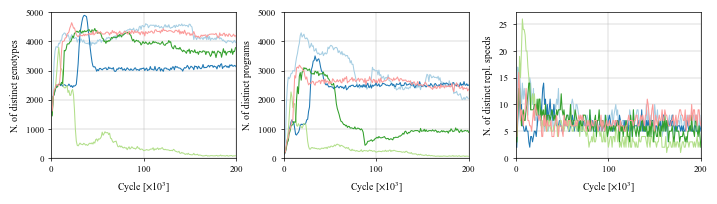

In [17]:
fig1 = make_figure(
    panels=[
        {"ylabel": "N. of distinct genotypes",
         "sources": [(load("distinct_genomes.tsv"), "-")],
         "ylim": (0, 5000)},
        {"ylabel": "N. of distinct programs",
         "sources": [(load("distinct_programs.tsv"), "-")],
         "ylim": (0, 5000)},
        {"ylabel": "N. of distinct repl. speeds",
         "sources": [(load("distinct_replication_speeds.tsv"), "-")],
         "ylim": (0, None)},
    ],
    filename="fig-population",
)
plt.show()

## Figure 2: Language make-up

Left: instructions per genome, defined (solid) against used (dashed). Middle: instruction
reuse. Right: micro-ops bundled per instruction. Set `legend=None` in the call below to match
the paper exactly, which explains the solid/dashed distinction in the caption instead.

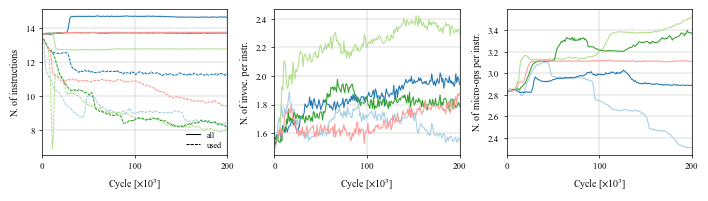

In [18]:
fig2 = make_figure(
    panels=[
        {"ylabel": "N. of instructions",
         "sources": [(load("instructions_defined.tsv"), "-"),
                     (load("instructions_used.tsv"), (0, (3, 1)))]},   # densely dashed
        {"ylabel": "N. of invoc. per instr.",
         "sources": [(load("instruction_reuse.tsv"), "-")]},
        {"ylabel": "N. of micro-ops per instr.",
         "sources": [(load("micro_ops_per_instruction.tsv"), "-")]},
    ],
    filename="fig-language",
    legend=[("all", "-"), ("used", (0, (3, 1)))],
)
plt.show()